In [68]:
## load packages 
import pandas as pd
import re
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

## nltk imports
from nltk.tokenize import word_tokenize, wordpunct_tokenize
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

## sklearn imports
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

## print mult things
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## random
import random

#state imports
import statsmodels.formula.api as smf

#geovis imports
import geopandas as gpd

#datetime imports
from datetime import date

#shapely imports
from shapely.geometry import Point

In [69]:
dfmerged = pd.read_csv('../data/hudsonmerged.csv')

,train_access,white_pct_change,black_pct_change,asian_pct_change,hispanic_pct_change,other_pct_change
0,hblr_only,-2.591044,-3.375403,2.366953,1.903513,0.465093
1,near_both,-2.304790,-0.824907,1.501595,0.089489,0.431920
2,near_neither,-3.821287,-0.819927,2.368653,0.298351,0.725507
3,path_only,-0.935575,-1.062751,3.718139,-2.883944,0.259766


<Figure size 1200x600 with 0 Axes>

<Axes: xlabel='train_access', ylabel='pct_change'>

Text(0.5, 1.0, 'Percentage Point Change in Racial Demographics (2010–2020)')

Text(0.5, 0, 'Proximity to Public Transit')

Text(0, 0.5, 'Percentage Point Change')

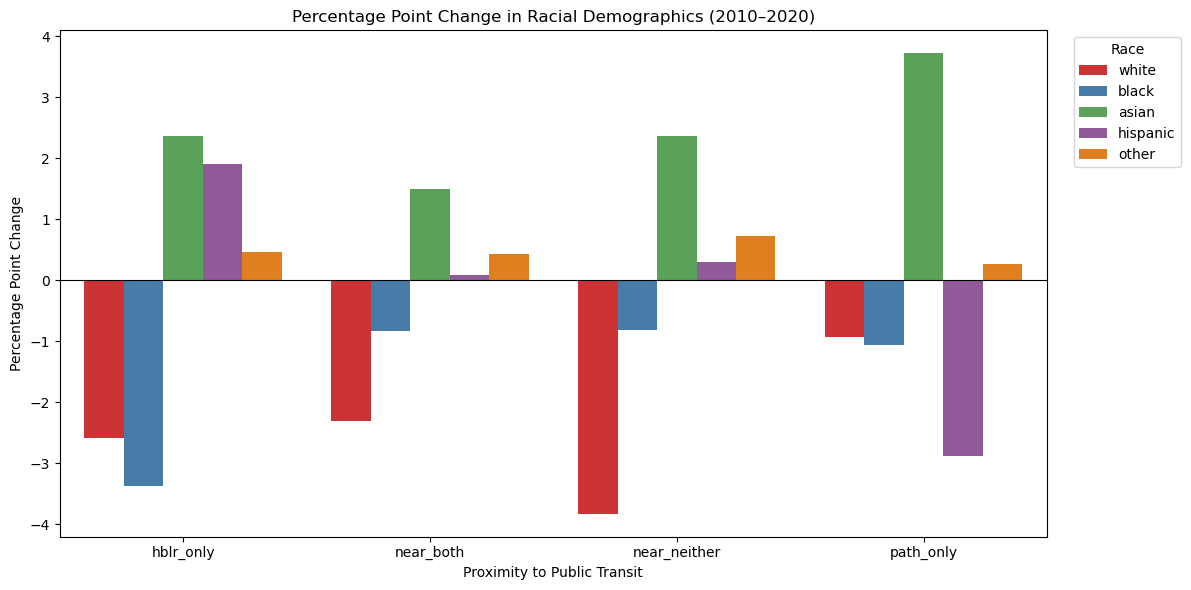

In [70]:
#creating initial plot to display grouped percentage point changes

#creating a grouped dataframe for plot
change_cols = ['white_pct_change', 'black_pct_change', 'asian_pct_change',
               'hispanic_pct_change', 'other_pct_change']

mergedgrouped = dfmerged.groupby('train_access')[change_cols].mean().reset_index()
mergedgrouped

long_df = mergedgrouped.melt(
    id_vars='train_access',
    value_vars=change_cols,
    var_name='race',
    value_name='pct_change'
)

# Clean up race labels (remove '_pct_change' suffix)
long_df['race'] = long_df['race'].str.replace('_pct_change', '', regex=False)

# Set up the plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=long_df,
    x='train_access',
    y='pct_change',
    hue='race',
    palette='Set1'
)

# Add a horizontal line at y=0 so negative bars are clearly visible
plt.axhline(0, color='black', linewidth=0.8)

# Labels and title
plt.title('Percentage Point Change in Racial Demographics (2010–2020)')
plt.xlabel('Proximity to Public Transit')
plt.ylabel('Percentage Point Change')
plt.legend(title='Race', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

plt.savefig("hudsonrace1.png", bbox_inches="tight")
plt.show()

In [71]:
#creating geovis

#importing shapefile
gdf = gpd.read_file("C:/Users/ryanm/Downloads/tl_2010_34017_tract10/tl_2010_34017_tract10.shp")
print(gdf.columns.tolist())  # find the tract identifier column
print(gdf.head())

['STATEFP10', 'COUNTYFP10', 'TRACTCE10', 'GEOID10', 'NAME10', 'NAMELSAD10', 'MTFCC10', 'FUNCSTAT10', 'ALAND10', 'AWATER10', 'INTPTLAT10', 'INTPTLON10', 'geometry']
  STATEFP10 COUNTYFP10 TRACTCE10      GEOID10 NAME10        NAMELSAD10  \
0        34        017    032400  34017032400    324  Census Tract 324   
1        34        017    010100  34017010100    101  Census Tract 101   
2        34        017    010200  34017010200    102  Census Tract 102   
3        34        017    010300  34017010300    103  Census Tract 103   
4        34        017    010400  34017010400    104  Census Tract 104   

  MTFCC10 FUNCSTAT10  ALAND10  AWATER10   INTPTLAT10    INTPTLON10  \
0   G5020          S   339545         0  +40.7928438  -074.0134817   
1   G5020          S  1055065   1065695  +40.6915587  -074.1109135   
2   G5020          S   293623         0  +40.6821027  -074.1045734   
3   G5020          S   970562    800475  +40.6724389  -074.0810163   
4   G5020          S  2214256   1567536  

In [72]:
#extracting tract num column and converting to float
gdf['tract_num'] = gdf['TRACTCE10'].astype(float) / 100

In [73]:
gdf_merged = gdf.merge(dfmerged, on='tract_num', how='left')

<Axes: >

<Axes: >

<Axes: >

(-74.16608699999999, -73.984883)

(40.642148999999996, 40.823569)

...

<Axes: >

(-74.16608699999999, -73.984883)

(40.642148999999996, 40.823569)

Text(0.5, 1.0, 'Other Population % Point Change 2010–2020')

(np.float64(-74.16608699999999),
 np.float64(-73.984883),
 np.float64(40.642148999999996),
 np.float64(40.823569))

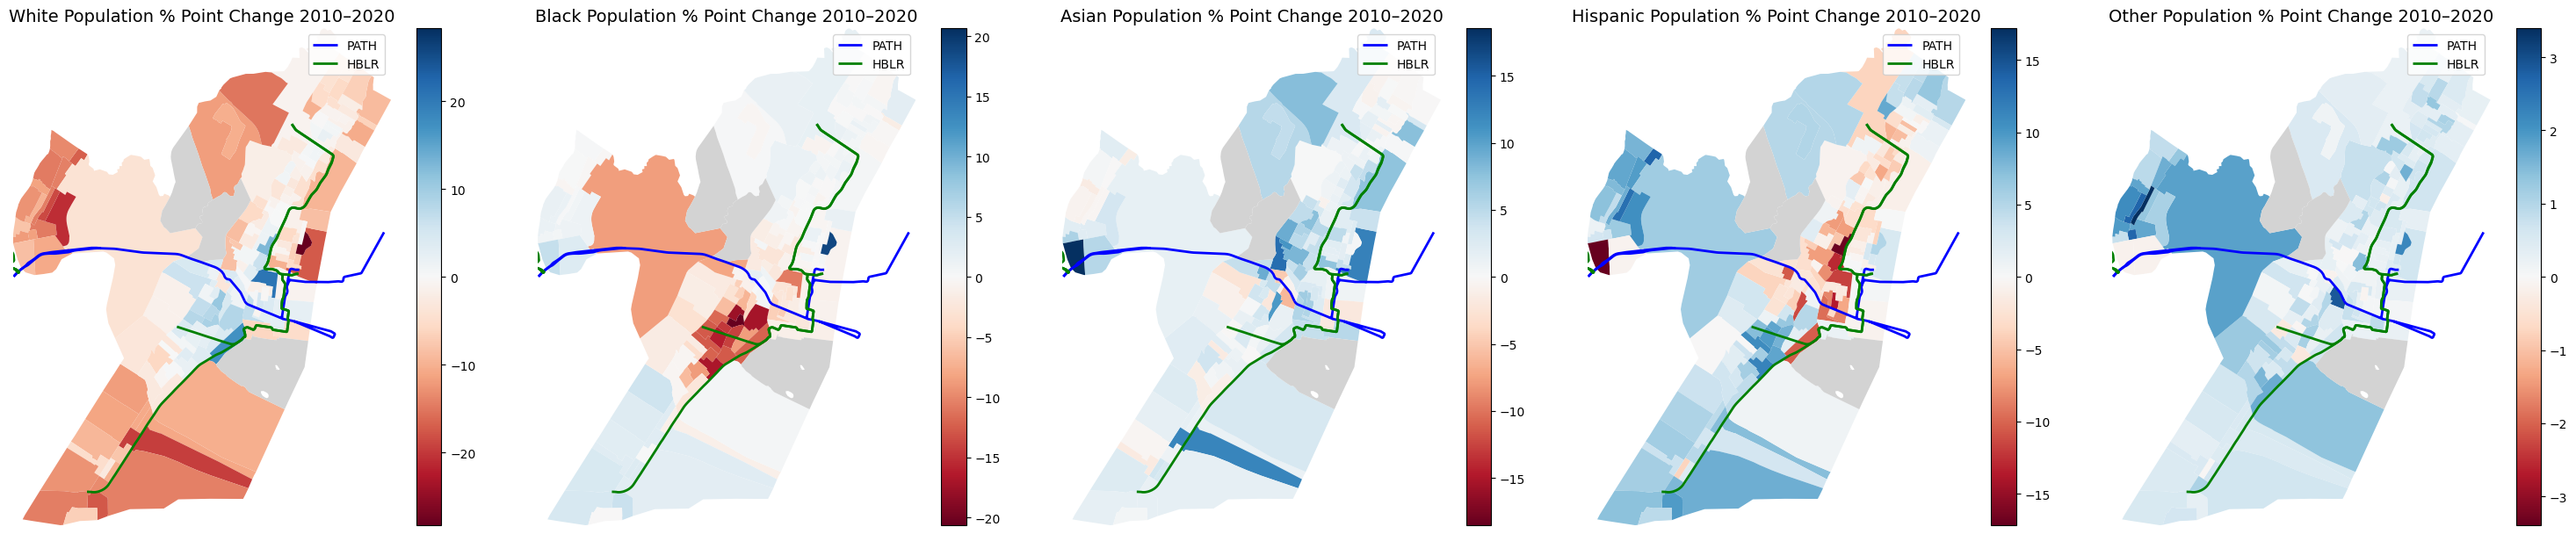

In [74]:
#importing transit line shapefiles
path = gpd.read_file("C:/Users/ryanm/Downloads/Path_Rail_Line/Path_Rail_Line.shp")
hblr = gpd.read_file('C:/Users/ryanm/Downloads/NJTransit_Light_Rail_4459803348782543118/Light_Rail_Lines_of_NJ_Transit.shp')

# ─── Reproject to match tract CRS ─────────────────────────────────────────────
path = path.to_crs(gdf_merged.crs)
hblr = hblr.to_crs(gdf_merged.crs)

# ─── Get Hudson County bounding box ───────────────────────────────────────────
minx, miny, maxx, maxy = gdf_merged.total_bounds

# ─── Plot one map per race ─────────────────────────────────────────────────────
races = ['white', 'black', 'asian', 'hispanic', 'other']

fig, axes = plt.subplots(1, len(races), figsize=(30, 6))

for ax, race in zip(axes, races):
    abs_max = np.abs(gdf_merged[f'{race}_pct_change']).max()
    
    gdf_merged.plot(
        column=f'{race}_pct_change',
        ax=ax,
        cmap='RdBu',
        vmin=-abs_max,
        vmax=abs_max,
        legend=True,
        missing_kwds={'color': 'lightgrey'}
    )
    
    path.plot(ax=ax, color='blue', linewidth=2, label='PATH')
    hblr.plot(ax=ax, color='green', linewidth=2, label='HBLR')
    
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    ax.legend()
    ax.set_title(f'{race.capitalize()} Population % Point Change 2010–2020', fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.savefig('race_pct_change_maps.png', dpi=150)
plt.show()

In [75]:
#using the imported shapefile to mark each tract with a distance to the central business district (marked in Downtown Jersey City)
cbd = Point(-74.0431, 40.7178)

gdf_projected = gdf_merged.to_crs(epsg=3424)
cbd_gdf = gpd.GeoDataFrame(geometry=[cbd], crs='EPSG:4326').to_crs(epsg=3424)

gdf_merged['dist_to_cbd_miles'] = gdf_projected.geometry.centroid.distance(cbd_gdf.geometry[0]) / 5280

dfmerged = dfmerged.merge(
    gdf_merged[['tract_num', 'dist_to_cbd_miles']], 
    on='tract_num', 
    how='left'
)

In [108]:
#Core controlled regression 

#Ordering categories so that near_neither will be the control
dfmerged['train_access'] = pd.Categorical(
    dfmerged['train_access'],
    categories=['near_neither', 'hblr_only', 'path_only', 'near_both']
)

models = {}
for race in ['white', 'black', 'asian', 'hispanic', 'other']:
    models[race] = smf.ols(
        f'{race}_pct_change ~ C(train_access) + median_income_2010 + dist_to_cbd_miles', #controlling for proximity to path, 2010 race, and distance to CBD
        data=dfmerged
    ).fit()
    print(f"\n=== {race} ===")
    print(models[race].summary())


=== white ===
                            OLS Regression Results                            
Dep. Variable:       white_pct_change   R-squared:                       0.552
Model:                            OLS   Adj. R-squared:                  0.538
Method:                 Least Squares   F-statistic:                     38.77
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           8.65e-26
Time:                        16:40:38   Log-Likelihood:                -487.16
No. Observations:                 163   AIC:                             986.3
Df Residuals:                     157   BIC:                             1005.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
I

          near_neither  hblr_only  path_only  near_both
white            12.35      12.09       8.16      12.51
black            -8.76     -10.57      -5.43      -7.77
asian             2.08       2.00       2.91      -1.04
hispanic         -6.13      -3.81      -5.80      -3.33
other             0.42       0.20       0.15       0.35


<ErrorbarContainer object of 3 artists>

Text(0.5, 1.0, 'White')

Text(0.5, 0, '% point difference\nvs near_neither')

<ErrorbarContainer object of 3 artists>

...

Text(0.5, 0, '% point difference\nvs near_neither')

<ErrorbarContainer object of 3 artists>

Text(0.5, 1.0, 'Other')

Text(0.5, 0, '% point difference\nvs near_neither')

Text(0.5, 1.02, 'Effect of Transit Access on Racial % Point Change 2010–2020\n(controlling for baseline race, income, distance to CBD)')

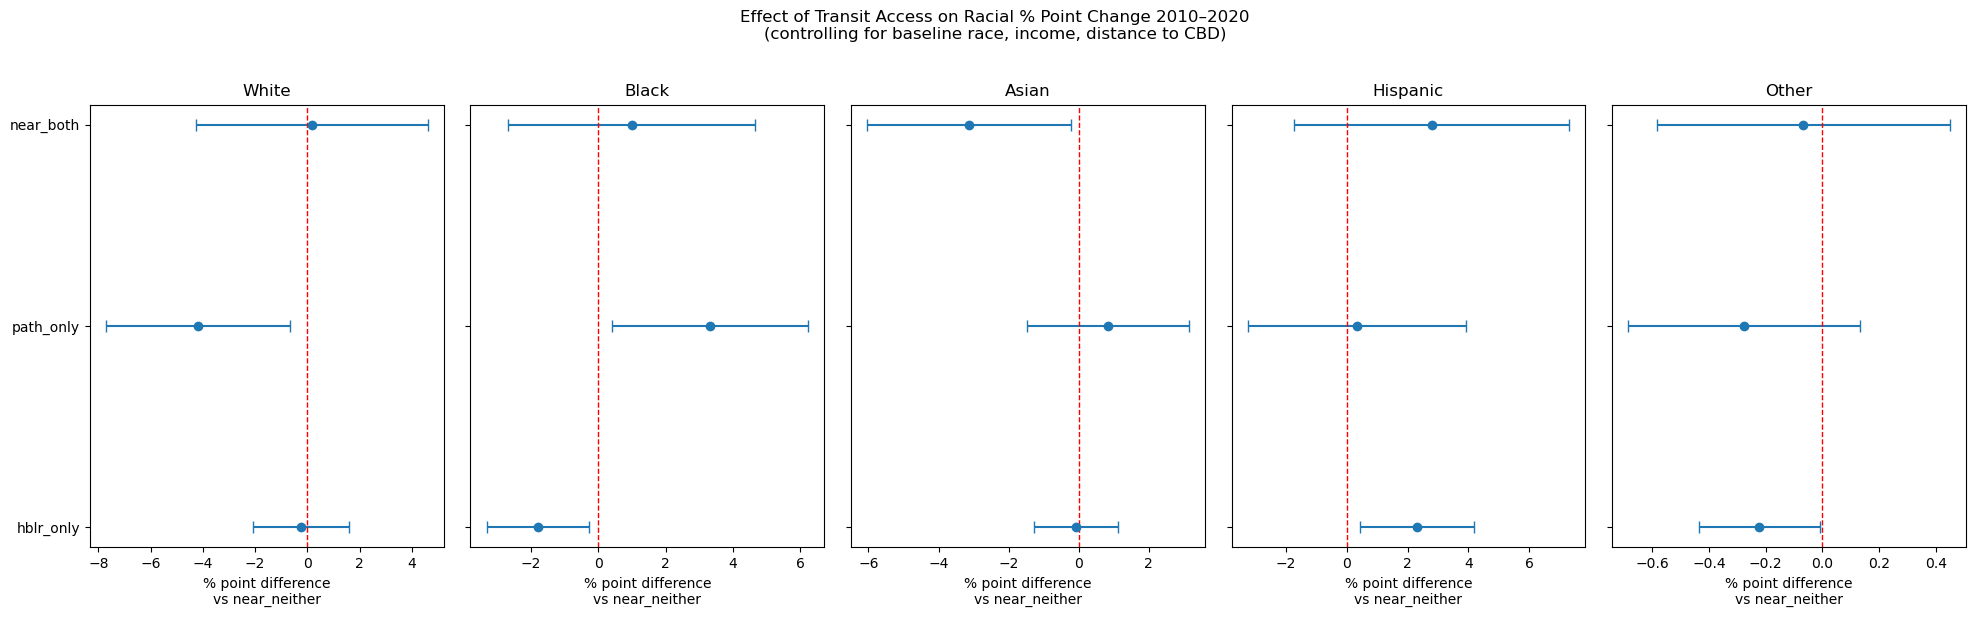

In [109]:
# ─── Summary table ─────────────────────────────────────────────────────────────
results = {}

for race in ['white', 'black', 'asian', 'hispanic', 'other']:
    results[race] = {
        'near_neither': models[race].params['Intercept'],
        'hblr_only': models[race].params['Intercept'] + models[race].params['C(train_access)[T.hblr_only]'],
        'path_only': models[race].params['Intercept'] + models[race].params['C(train_access)[T.path_only]'],
        'near_both': models[race].params['Intercept'] + models[race].params['C(train_access)[T.near_both]'],
    }

summary = pd.DataFrame(results).T.round(2)
print(summary)

# ─── Coefficient plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 6), sharey=True)

for ax, race in zip(axes, ['white', 'black', 'asian', 'hispanic', 'other']):
    model = models[race]
    
    # Extract treatment coefficients only (drop intercept and controls)
    coef_names = ['C(train_access)[T.hblr_only]', 
                  'C(train_access)[T.path_only]', 
                  'C(train_access)[T.near_both]']
    labels = ['hblr_only', 'path_only', 'near_both']
    
    coefs = [model.params[c] for c in coef_names]
    ci_low = [model.conf_int().loc[c, 0] for c in coef_names]
    ci_high = [model.conf_int().loc[c, 1] for c in coef_names]
    
    xerr_low = [coefs[i] - ci_low[i] for i in range(3)]
    xerr_high = [ci_high[i] - coefs[i] for i in range(3)]
    
    ax.errorbar(coefs, labels, xerr=[xerr_low, xerr_high], fmt='o', capsize=4)
    ax.axvline(0, color='red', linestyle='--', linewidth=1)
    ax.set_title(race.capitalize())
    ax.set_xlabel('% point difference\nvs near_neither')

plt.suptitle('Effect of Transit Access on Racial % Point Change 2010–2020\n(controlling for baseline race, income, distance to CBD)', 
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('coefficient_plot_controlled.png', dpi=150)
plt.show()

In [80]:
# ─── Inflation adjustment (2010 to 2020 dollars) ──────────────────────────────
cpi_2010 = 218.056
cpi_2020 = 258.811
inflation_factor = cpi_2020 / cpi_2010  # ≈ 1.187

# Adjust 2010 values to 2020 dollars
dfmerged['median_income_2010_adj']     = dfmerged['median_income_2010'] * inflation_factor
dfmerged['median_rent_2010_adj']       = dfmerged['median_rent_2010'] * inflation_factor
dfmerged['median_house_2010_adj'] = dfmerged['median_house_2010'] * inflation_factor

# Recompute change variables in real terms
dfmerged['income_change']     = dfmerged['median_income_2020'] - dfmerged['median_income_2010_adj']
dfmerged['rent_change']       = dfmerged['median_rent_2020']   - dfmerged['median_rent_2010_adj']
dfmerged['home_value_change'] = dfmerged['median_house_2020'] - dfmerged['median_house_2010_adj']

print(f"Inflation factor: {inflation_factor:.3f}")
print(f"\nIncome change (real): {dfmerged['income_change'].mean():.0f}")
print(f"Rent change (real): {dfmerged['rent_change'].mean():.0f}")
print(f"Home value change (real): {dfmerged['home_value_change'].mean():.0f}")

Inflation factor: 1.187

Income change (real): 9577
Rent change (real): 180
Home value change (real): -39298


<BarContainer object of 1 artists>

<BarContainer object of 1 artists>

<BarContainer object of 1 artists>

<BarContainer object of 1 artists>

<BarContainer object of 1 artists>

...

<BarContainer object of 1 artists>

[Text(0, 0, 'hblr'), Text(1, 0, 'path'), Text(2, 0, 'both')]

Text(0.5, 1.0, 'Other\n(Home Value Change)')

Text(0, 0.5, 'Coefficient')

Text(0.5, 1.01, 'Transit Coefficients Before and After Mediators\n(dark = without mediator, light = with mediator, green = p<0.05, grey = ns)')

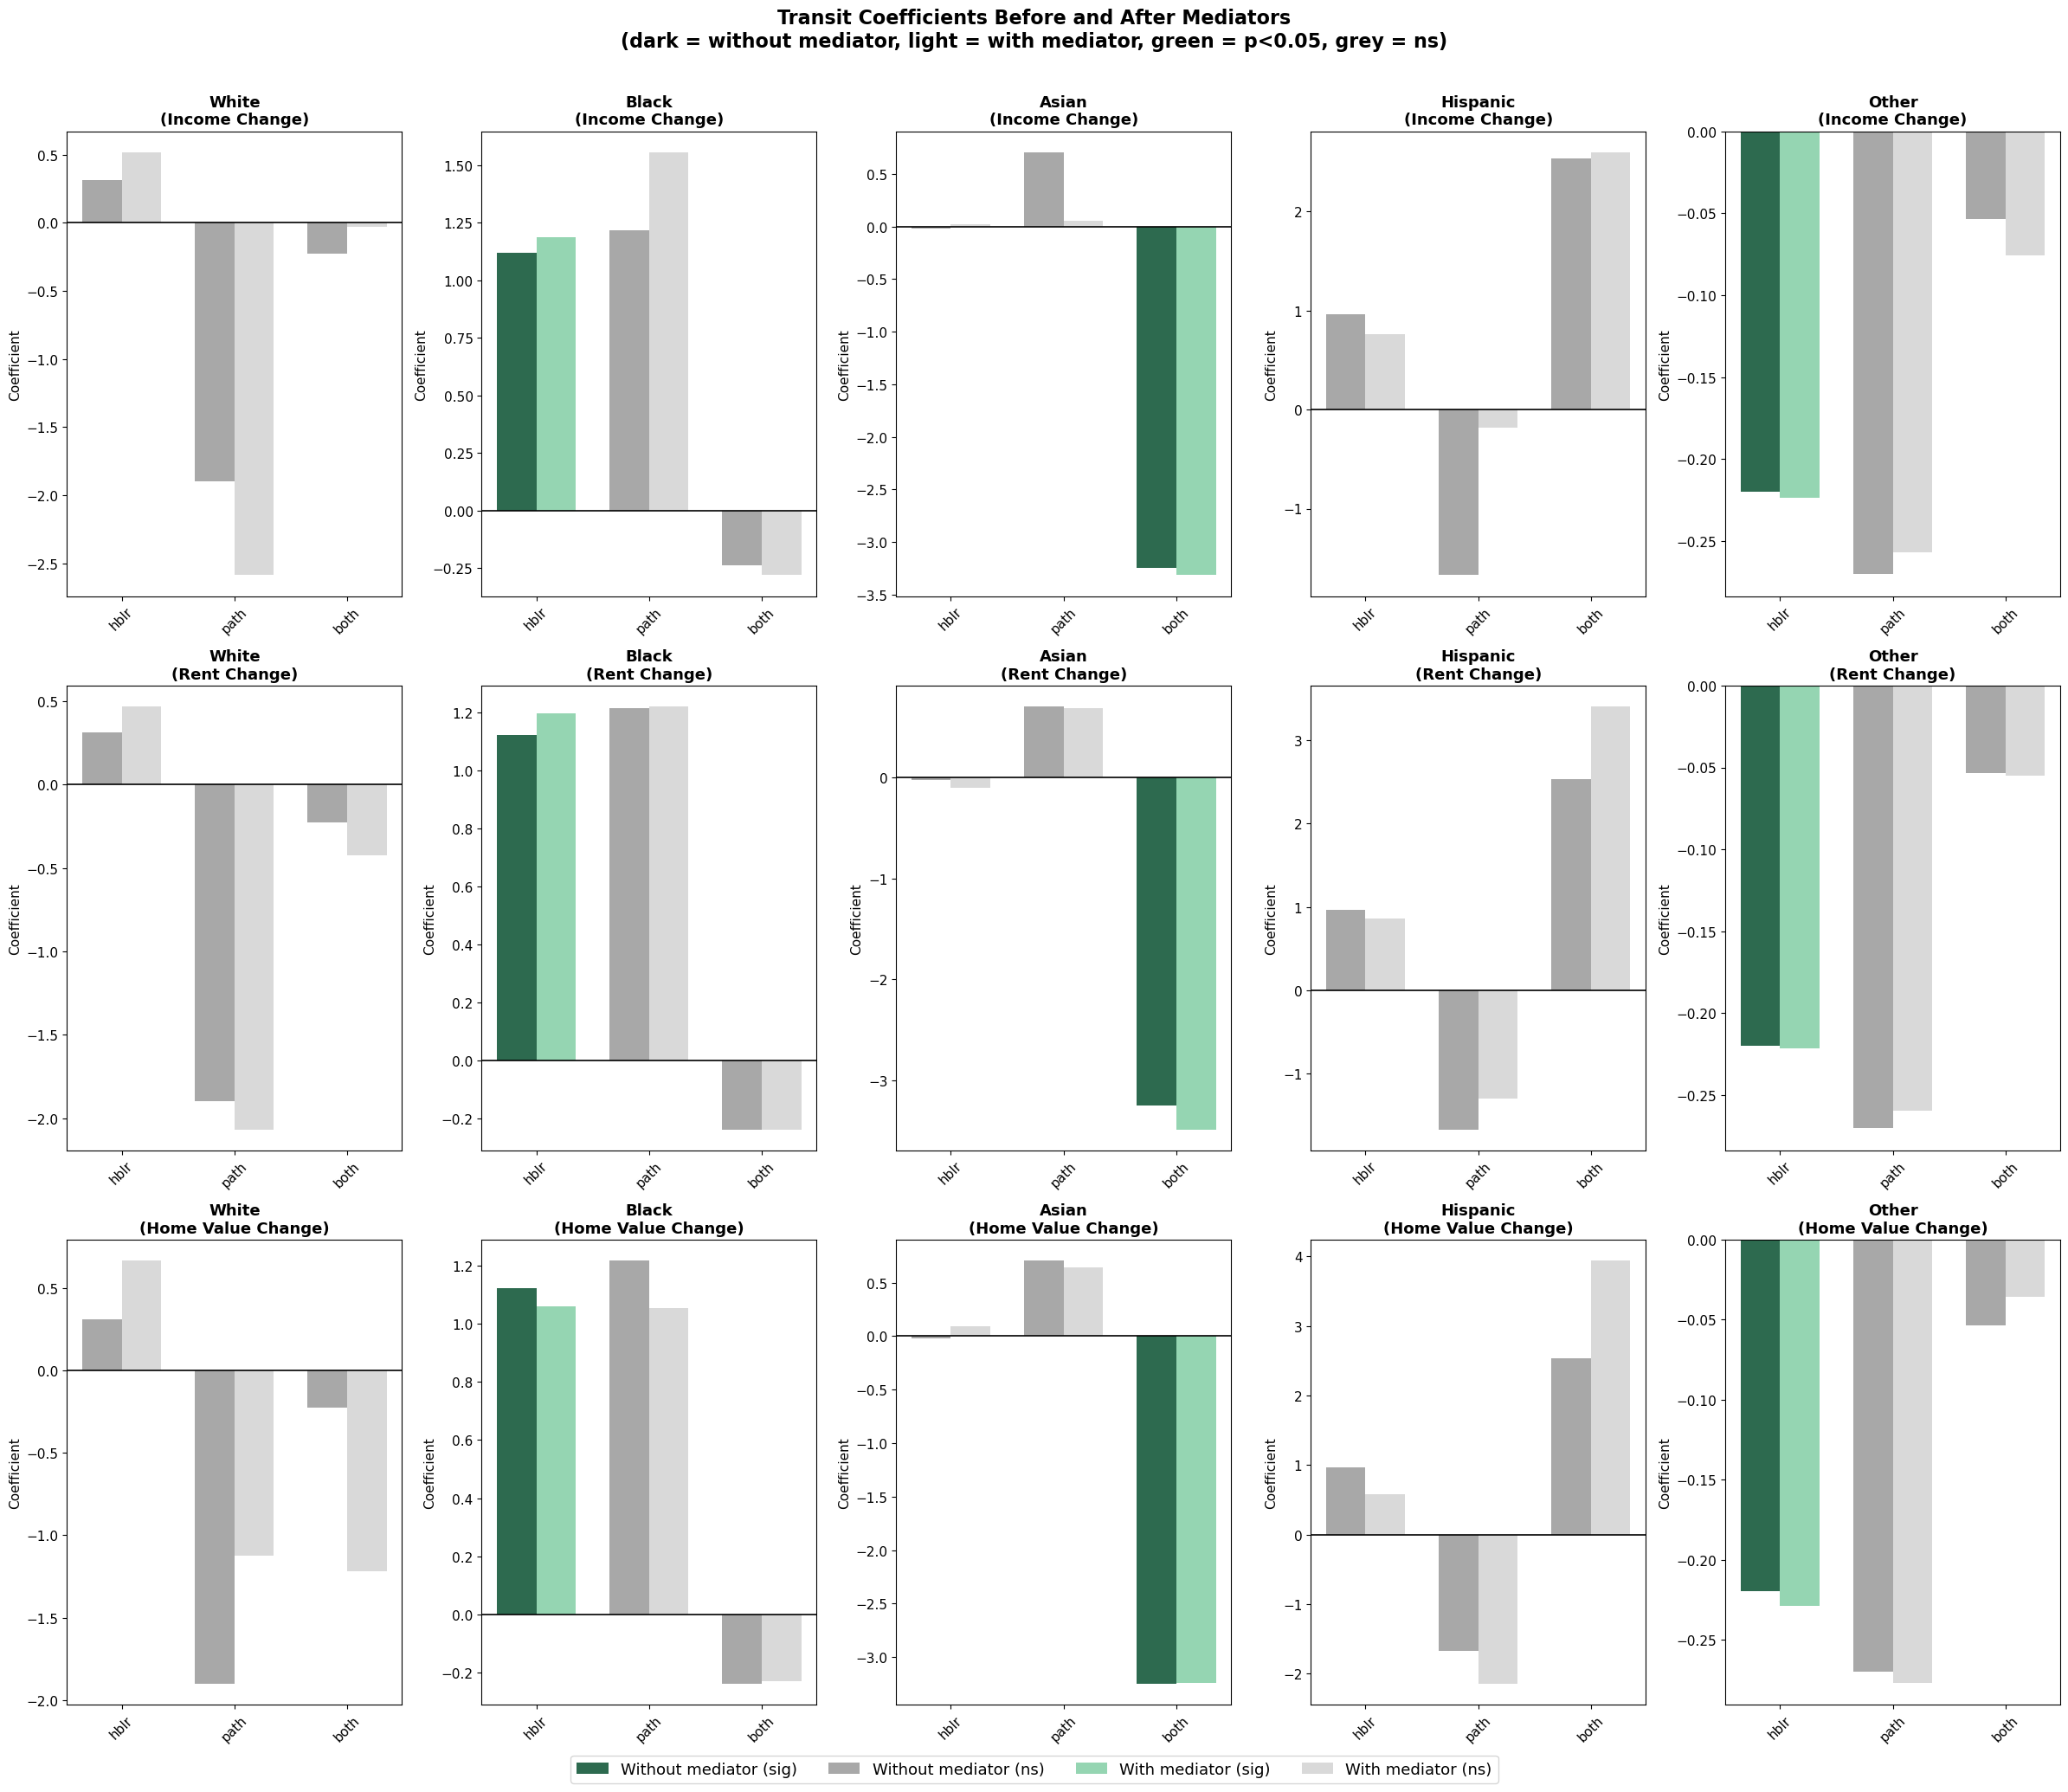

In [110]:
#conducting mediation analysis
mediator_labels = {
    'income_change':     'Income Change',
    'rent_change':       'Rent Change',
    'home_value_change': 'Home Value Change',
}

fig, axes = plt.subplots(3, 5, figsize=(24, 20), sharey=False)
groups = ['hblr', 'path', 'both']
x = np.arange(len(groups))
width = 0.35

#using a loop to apply the same code to conduct mediation analysis of all three potential mediators
for row, mediator_name in enumerate(mediator_labels.keys()):
    for col, race in enumerate(['white', 'black', 'asian', 'hispanic', 'other']):
        ax = axes[row, col]
        res = mediation_results_all[mediator_name][race]

        for i, group in enumerate(groups):
            coef_without = res[f'{group}_without_mediator']
            coef_with    = res[f'{group}_with_mediator']
            p_without    = res[f'{group}_p_without']
            p_with       = res[f'{group}_p_with']

            ax.bar(x[i] - width/2, coef_without, width,
                   color='#2d6a4f' if p_without < 0.05 else '#a8a8a8')
            ax.bar(x[i] + width/2, coef_with, width,
                   color='#95d5b2' if p_with < 0.05 else '#d9d9d9')

        ax.axhline(0, color='black', linewidth=1.2)
        ax.set_xticks(x)
        ax.set_xticklabels(groups, rotation=45, fontsize=11)
        ax.tick_params(axis='y', labelsize=11)
        ax.set_title(f'{race.capitalize()}\n({mediator_labels[mediator_name]})', fontsize=13, fontweight='bold')
        ax.set_ylabel('Coefficient', fontsize=11)

#creating barplot graphics 
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2d6a4f', label='Without mediator (sig)'),
    Patch(facecolor='#a8a8a8', label='Without mediator (ns)'),
    Patch(facecolor='#95d5b2', label='With mediator (sig)'),
    Patch(facecolor='#d9d9d9', label='With mediator (ns)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.02), fontsize=13)

plt.suptitle('Transit Coefficients Before and After Mediators\n(dark = without mediator, light = with mediator, green = p<0.05, grey = ns)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('mediation_all_plot_v3.png', dpi=150, bbox_inches='tight')
plt.show()

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

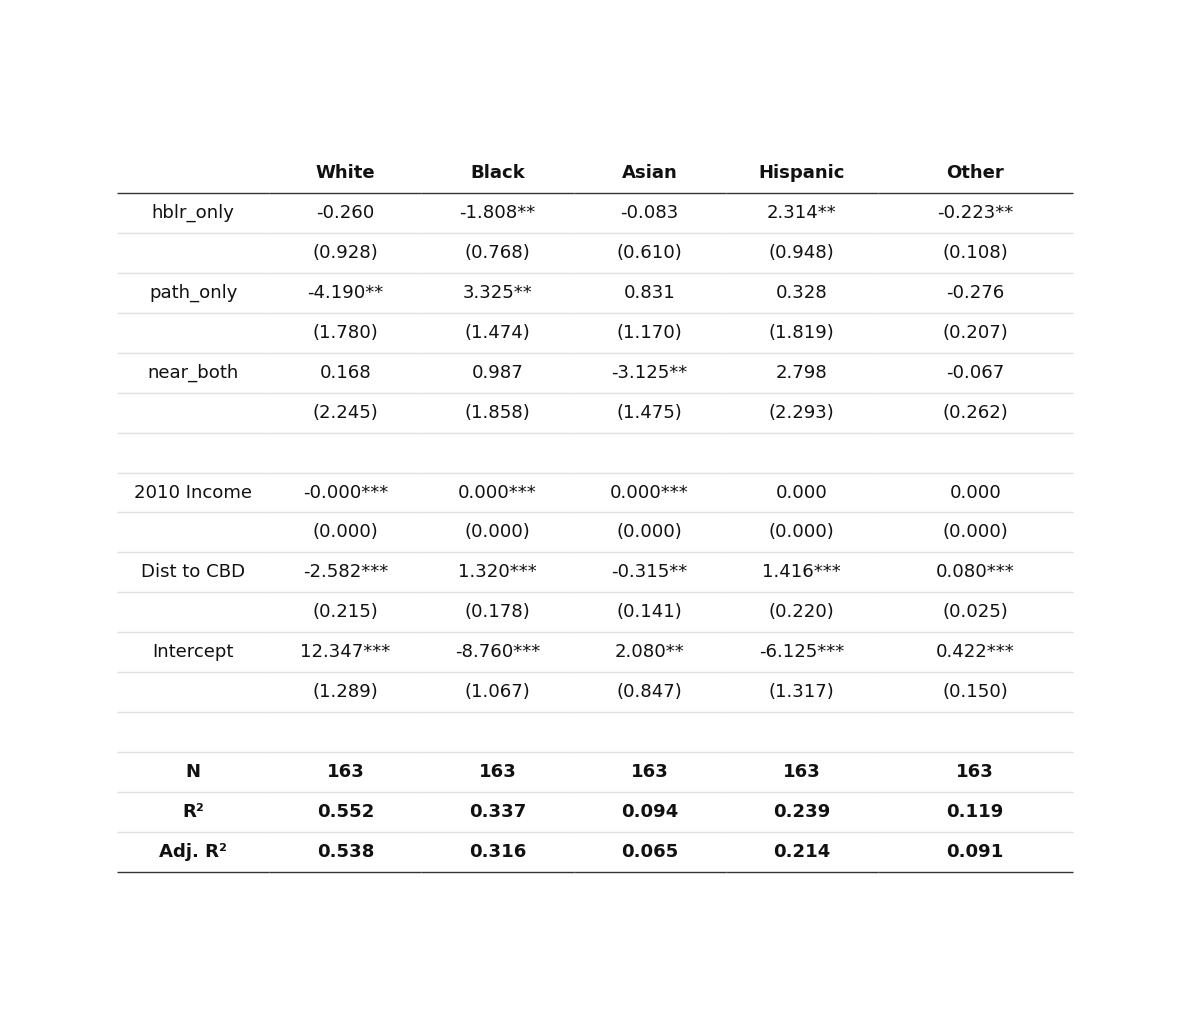

In [111]:
#creating minimalist table visualization for original OLS regression results
races = ['white', 'black', 'asian', 'hispanic', 'other']
groups = ['hblr_only', 'path_only', 'near_both']
control_labels = ['2010 Income', 'Dist to CBD', 'Intercept']
control_params = ['median_income_2010', 'dist_to_cbd_miles', 'Intercept']

def fmt_coef(coef, p):
    stars = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
    return f'{coef:.3f}{stars}'

def fmt_se(se):
    return f'({se:.3f})'

# ─── Build rows ────────────────────────────────────────────────────────────────
rows = []

for group in groups:
    param = f'C(train_access)[T.{group}]'
    coef_row = [fmt_coef(models[race].params[param], models[race].pvalues[param]) for race in races]
    se_row   = [fmt_se(models[race].bse[param]) for race in races]
    rows.append([group] + coef_row)
    rows.append([''] + se_row)

rows.append([''] + [''] * len(races))

for label, param_template in zip(control_labels, control_params):
    coef_row = [fmt_coef(models[race].params[param_template.replace('{race}', race)],
                         models[race].pvalues[param_template.replace('{race}', race)]) for race in races]
    se_row   = [fmt_se(models[race].bse[param_template.replace('{race}', race)]) for race in races]
    rows.append([label] + coef_row)
    rows.append([''] + se_row)

rows.append([''] + [''] * len(races))
rows.append(['N']       + [str(int(models[race].nobs)) for race in races])
rows.append(['R²']      + [f'{models[race].rsquared:.3f}' for race in races])
rows.append(['Adj. R²'] + [f'{models[race].rsquared_adj:.3f}' for race in races])

# ─── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, len(rows) * 0.55 + 1))
ax.axis('off')

col_labels = [''] + [r.capitalize() for r in races]

table = ax.table(
    cellText=rows,
    colLabels=col_labels,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(13)
table.scale(1.0, 1.9)

# ─── Set column widths ────────────────────────────────────────────────────────
col_widths = [0.18] + [0.13] * len(races)
for col_idx, width in enumerate(col_widths):
    for row_idx in range(len(rows) + 1):
        try:
            table[row_idx, col_idx - 1].set_width(width)
        except KeyError:
            pass

# ─── Styling ───────────────────────────────────────────────────────────────────
n_rows = len(rows)

for (row, col), cell in table.get_celld().items():
    cell.set_facecolor('white')
    cell.visible_edges = 'B'
    cell.set_edgecolor('#e0e0e0')
    cell.set_text_props(color='#111111')

    if row == 0:
        cell.set_text_props(fontweight='bold', color='#111111')
        cell.set_edgecolor('#333333')

    if col == -1:
        cell.set_text_props(color='#111111', ha='left')

    if row > 0 and rows[row - 1][0] in ['N', 'R²', 'Adj. R²']:
        cell.set_text_props(fontweight='bold', color='#111111')

    if row == n_rows:
        cell.visible_edges = 'B'
        cell.set_edgecolor('#333333')

plt.tight_layout()
plt.savefig('regression_table_minimal_v6.png', dpi=150, bbox_inches='tight')
plt.show()